# Training of a WGAN on disk images.

In [1]:
import functools as ft
import os
from collections.abc import Callable, Iterable, Iterator
from pathlib import Path
from typing import Any

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax

from organic.training_data import TrainingImgLoader

## Defining abstract classes for generators and critics

In [2]:
# class GeneratorAbstract(eqx.Module):
#     """Abstract class for a generator. The only requirements is that it is a callable
#     Equinox module, taking in a 1D vector JAX array and returning a 3D image (Y, X,
#     Channel indexing) cube.
#     """

#     @abc.abstractmethod
#     def __call__(self, x: jax.Array) -> jax.Array:
#         """Feed-forward pass through the neural network.

#         **Arguments**

#         - `x`: 1D input vector.

#         **Returns**

#         A 3D image (Y, X, Channel indexing) cube as a JAX array.
#         """
#         raise NotImplementedError


# @abc.abstractmethod
# class CriticAbstract(eqx.Module):
#     """Abstract class for a critic. The only requirements is that it is a callable
#     Equinox module, taking in 3D image (Y, X, Channel indexing) cube and returning.
#     """

#     def __call__(self, x: jax.Array) -> jax.Array:
#         """Feed-forward pass through the neural network.

#         **Arguments**

#         - `x`: A 3D image (Y, X, Channel indexing) cube array.

#         **Returns**

#         A shape (1,) scalar meant to represent the Wasserstein distance estimate.
#         """
#         raise NotImplementedError

In [ ]:
# TODO: make these compatible with stateful layers


class GeneratorDisksNIROld(eqx.Module):
    """WGAN generator for monochromatic NIR disk images.

    **Attributes**

    - `layers`: Tuple containing the different neural network layers. The only
        requirement is that each layer should just be callable using the output of the
        preceding layer. The first layer needs to be able to accept a latent 'noise'
        vector of size `size_in`.
    - `size_in`: Size of the latent 'noise' input vector to the first layer.
    """

    layers: tuple[Any, ...]  # Different callable layers.
    size_in: int = eqx.field(static=True)  # Size of input latent vector.

    # TODO: implement
    def __init__(self, key: jax.Array) -> None:
        """**Arguments**

        - `key`: JAX PRNG key to initialise the model.
        """
        key, subkey1, subkey2, subkey3, subkey4, subkey5 = jax.random.split(key, 6)

        self.size_in = 100
        self.layers = (
            eqx.nn.Linear(
                100, 256 * 16 * 16, use_bias=True, key=subkey1
            ),  # Fully connected.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Lambda(
                lambda x: jnp.reshape(x, shape=(256, 16, 16))
            ),  # Reshape to 256 x 16 x 16.
            eqx.nn.ConvTranspose2d(
                in_channels=256,
                out_channels=128,
                kernel_size=(4, 4),
                stride=(2, 2),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey2,
            ),  # Transposed convolution to 128 x 32 x 32.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.ConvTranspose2d(
                in_channels=128,
                out_channels=64,
                kernel_size=(4, 4),
                stride=(2, 2),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey3,
            ),  # Transposed convolution to 64 x 64 x 64.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.ConvTranspose2d(
                in_channels=64,
                out_channels=32,
                kernel_size=(4, 4),
                stride=(2, 2),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey4,
            ),  # Transposed convolution to 32 x 128 x 128.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Conv2d(
                in_channels=32,
                out_channels=1,
                kernel_size=(5, 5),
                stride=(1, 1),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey5,
            ),  # Final regular convolution to 1 x 128 x 128.
            eqx.nn.Lambda(
                lambda x: jnp.tanh(x)
            ),  # Final activation to map to signed unit interval [-1, 1].
        )
        return

    def __call__(
        self, x: jax.Array, state: eqx.nn.State
    ) -> tuple[jax.Array, eqx.nn.State]:
        """Feed-forward pass through the generator neural network.

        **Arguments**

        - `x`: 1D input vector.

        - `state`: The current state of the generator.

        **Returns**

        A 3D image (Y, X, Channel indexing) cube as a JAX array and the updated
        state of the generator.
        """
        print(f"SHAPE OF INPUT X: {x.shape}")
        for layer in self.layers:
            print(f"CURRENTLY CONSIDERING LAYER OF TYPE '{type(layer)}'")
            if layer.is_stateful():
                x, state = layer(x, state)
            else:
                x = layer(x)
            print(f"OUTPUT SHAPE: {x.shape}")
        return x, state


class GeneratorDisksNIR(eqx.Module):
    """WGAN generator for monochromatic NIR disk images with upsampling.

    **Attributes**

    - `layers`: Tuple containing the different neural network layers. The only
        requirement is that each layer should just be callable using the output of the
        preceding layer, producing a 3D image (Y, X, Channel indexing) cube from an
        input 1D latent vector of given `size_in`.
    - `size_in`: Size of the latent 'noise' input vector to the first layer.
    """

    layers: tuple[Any, ...]  # Different callable layers.
    size_in: int = eqx.field(static=True)  # Size of input latent vector.

    # TODO: implement
    def __init__(self, key: jax.Array) -> None:
        """**Arguments**

        - `key`: JAX PRNG key to initialise the model.
        """
        key, subkey1, subkey2, subkey3, subkey4, subkey5 = jax.random.split(key, 6)

        self.size_in = 100
        self.layers = (
            eqx.nn.Linear(
                self.size_in, 256 * 16 * 16, use_bias=True, key=subkey1
            ),  # Fully connected from shape (100,) to (256 * 16 * 16,).
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Lambda(
                lambda x: jnp.reshape(x, shape=(256, 16, 16))
            ),  # Reshape to 256 x 16 x 16.
            eqx.nn.Lambda(
                lambda x: jnp.repeat(
                    jnp.repeat(x, repeats=2, axis=1),
                    2,
                    axis=2,
                )
            ),  # Upsample to 256 x 32 x 32.
            eqx.nn.Conv2d(
                in_channels=256,
                out_channels=128,
                kernel_size=(3, 3),
                stride=(1, 1),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey2,
            ),  # Regular convolution to 128 x 32 x 32.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Lambda(
                lambda x: jnp.repeat(
                    jnp.repeat(x, repeats=2, axis=1),
                    2,
                    axis=2,
                )
            ),  # Upsample to 128 x 64 x 64.
            eqx.nn.Conv2d(
                in_channels=128,
                out_channels=64,
                kernel_size=(3, 3),
                stride=(1, 1),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey3,
            ),  # Regular convolution to 64 x 64 x 64.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Lambda(
                lambda x: jnp.repeat(
                    jnp.repeat(x, repeats=2, axis=1),
                    repeats=2,
                    axis=2,
                )
            ),  # Upsample to 64 x 128 x 128.
            eqx.nn.Conv2d(
                in_channels=64,
                out_channels=32,
                kernel_size=(3, 3),
                stride=(1, 1),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey4,
            ),  # Regular convolution to 32 x 128 x 128.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Conv2d(
                in_channels=32,
                out_channels=1,
                kernel_size=(5, 5),
                stride=(1, 1),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey5,
            ),  # Final regular convolution to 1 x 128 x 128.
            eqx.nn.Lambda(
                lambda x: jnp.tanh(x)
            ),  # Final activation to map to signed unit interval [-1, 1].
        )
        return

    def __call__(
        self, x: jax.Array, state: eqx.nn.State
    ) -> tuple[jax.Array, eqx.nn.State]:
        """Feed-forward pass through the generator neural network.

        **Arguments**

        - `x`: 1D input vector.

        - `state`: The current state of the generator.

        **Returns**

        A 3D image (Y, X, Channel indexing) cube as a JAX array and the updated
        state of the generator.
        """
        print(f"SHAPE OF INPUT X: {x.shape}")
        for layer in self.layers:
            print(f"CURRENTLY CONSIDERING LAYER OF TYPE '{type(layer)}'")
            if layer.is_stateful():
                x, state = layer(x, state)
            else:
                x = layer(x)
            print(f"OUTPUT SHAPE: {x.shape}")
        return x, state


# TODO: upgrade to be stateful with spectral normalization to enforce Lipschitz
# constraint
class CriticDisksNIR(eqx.Module):
    """WGAN critic for monochromatic NIR disk images.

    **Attributes**

    - `layers`: Tuple containing the different neural network layers. The only
        requirement is that each layer should just be callable using the output of the
        preceding layer. The first layer needs to be able to accept a 3D image (Y, X,
        Channel indexing) cube.
    """

    layers: tuple[Any, ...]  # Different callable layers.

    def __init__(self, key: jax.Array) -> None:
        """**Arguments**

        - `key`: JAX PRNG key to initialise the model.
        """
        key, subkey1, subkey2, subkey3, subkey4, subkey5 = jax.random.split(key, 6)

        self.layers = (
            eqx.nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=(5, 5),
                stride=(2, 2),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey1,
            ),  # Regular convolution to 32 x 64 x 64 (assuming input is 1 x 128 x 128).
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.25)
            ),  # Activation.
            eqx.nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=(3, 3),
                stride=(2, 2),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey2,
            ),  # Regular convolution to 64 x 32 x 32.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.25)
            ),  # Activation.
            eqx.nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=(3, 3),
                stride=(2, 2),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey3,
            ),  # Regular convolution to 128 x 16 x 16.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.25)
            ),  # Activation.
            eqx.nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=(3, 3),
                stride=(1, 1),
                padding="SAME",
                padding_mode="ZEROS",
                use_bias=True,
                key=subkey4,
            ),  # Regular convolution to 256 x 16 x 16.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.25)
            ),  # Activation.
            eqx.nn.Lambda(lambda x: jnp.ravel(x)),  # Ravel to shape (256 * 16 * 16,)
            eqx.nn.Linear(
                256 * 16 * 16, 1, use_bias=True, key=subkey5
            ),  # Final activation to scalar of shape (1,)
        )

        return

    def __call__(
        self, x: jax.Array, state: eqx.nn.State
    ) -> tuple[jax.Array, eqx.nn.State]:
        """Feed-forward pass through the neural network.

        **Arguments**

        - `x`: A 3D image (Y, X, Channel indexing) cube array.

        - `state`: The current state of the critic.

        **Returns**

        A shape (1,) scalar meant to represent the Wasserstein distance estimate and
        the updated state of the critic.
        """
        print("\n")
        print(f"SHAPE OF INPUT X: {x.shape}")
        for layer in self.layers:
            print(f"CURRENTLY CONSIDERING LAYER OF TYPE '{type(layer)}'")
            if layer.is_stateful():
                x, state = layer(x, state)
            else:
                x = layer(x)
            print(f"OUTPUT SHAPE: {x.shape}")
        return x, state



SHAPE OF INPUT X: (100,)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._linear.Linear'>'
OUTPUT SHAPE: (65536,)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (65536,)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (256, 16, 16)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (256, 32, 32)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._conv.Conv2d'>'
OUTPUT SHAPE: (128, 32, 32)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (128, 32, 32)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (128, 64, 64)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._conv.Conv2d'>'
OUTPUT SHAPE: (64, 64, 64)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (64, 64, 64)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'eq

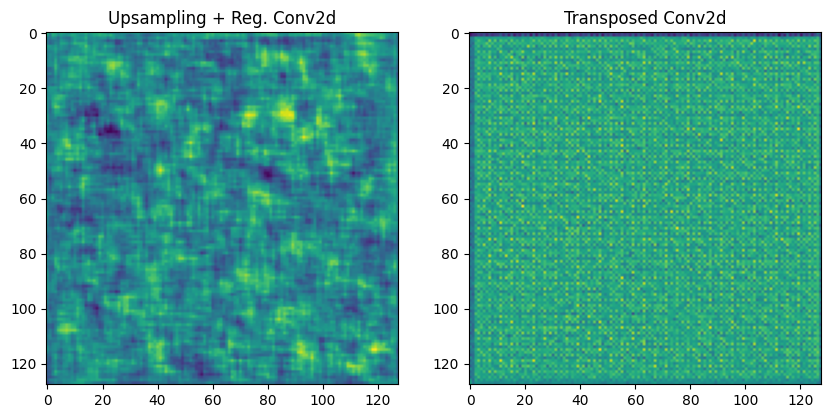

In [4]:
key = jax.random.key(42)
key, subkey1, subkey2, subkey3 = jax.random.split(key, 4)

gen_notrans = GeneratorDisksNIR(key=subkey1)
gen_trans = GeneratorDisksNIROld(key=subkey2)

key, subkey = jax.random.split(key, 2)
z_test = jax.random.normal(subkey3, shape=(100,))
test_pass_notrans = gen_notrans(z_test)
test_pass_trans = gen_trans(z_test)

fig, ax = plt.subplots(1, 2, figsize=(10, 10))
ax[0].imshow(test_pass_notrans[0, :, :])
ax[0].set_title("Upsampling + Reg. Conv2d")
ax[1].imshow(test_pass_trans[0, :, :])
ax[1].set_title("Transposed Conv2d")
plt.savefig("/home/toond/Downloads/compare.png", dpi=200)
plt.show()

In [5]:
key, subkey = jax.random.split(key, 2)
crit = CriticDisksNIR(key=key)

key, subkey = jax.random.split(key, 2)
img_test = jax.random.normal(subkey, shape=(1, 128, 128))

w_test = crit(img_test)



SHAPE OF INPUT X: (1, 128, 128)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._conv.Conv2d'>'
OUTPUT SHAPE: (32, 64, 64)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (32, 64, 64)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._conv.Conv2d'>'
OUTPUT SHAPE: (64, 32, 32)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (64, 32, 32)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._conv.Conv2d'>'
OUTPUT SHAPE: (128, 16, 16)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (128, 16, 16)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._conv.Conv2d'>'
OUTPUT SHAPE: (256, 16, 16)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (256, 16, 16)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (65536,)
CURRENTLY CONSIDERING LAYER OF TYPE '<class '

In [6]:
print(gen_notrans)

GeneratorDisksNIR(
  layers=(
    Linear(
      weight=f32[65536,100],
      bias=f32[65536],
      in_features=100,
      out_features=65536,
      use_bias=True
    ),
    Lambda(fn=<function GeneratorDisksNIR.__init__.<locals>.<lambda>>),
    Lambda(fn=<function GeneratorDisksNIR.__init__.<locals>.<lambda>>),
    Lambda(fn=<function GeneratorDisksNIR.__init__.<locals>.<lambda>>),
    Conv2d(
      num_spatial_dims=2,
      weight=f32[128,256,3,3],
      bias=f32[128,1,1],
      in_channels=256,
      out_channels=128,
      kernel_size=(3, 3),
      stride=(1, 1),
      padding='SAME',
      dilation=(1, 1),
      groups=1,
      use_bias=True,
      padding_mode='ZEROS'
    ),
    Lambda(fn=<function GeneratorDisksNIR.__init__.<locals>.<lambda>>),
    Lambda(fn=<function GeneratorDisksNIR.__init__.<locals>.<lambda>>),
    Conv2d(
      num_spatial_dims=2,
      weight=f32[64,128,3,3],
      bias=f32[64,1,1],
      in_channels=128,
      out_channels=64,
      kernel_size=(3, 3),
  

### Auxiliary function definitions

#### Loss functions

In [ ]:
# TODO: make compatible with both critic and gen being stateful.
def _wgan_gen_loss(gen_params, gen_static, crit_params, crit_static, crit_state, z_in):
    """Get the generator's loss value when evaluating a batch of random 1D latent input
    vectors. Note that this forces the critic to be considered in inference mode.

    **Arguments**

    - `gen_params`: The generator's trainable parameters. This should generally only
        include components that return `True` under `eqx.is_array`.
    - `gen_static`: The generator's non-trainable components. This should generally only
        include components that return `False` under `eqx.is_array`.
    - `crit_params`: The critic's trainable parameters. This should generally only
        include components that return `True` under `eqx.is_array`.
    - `crit_static`: The critic's non-trainable components. This should generally only
        include components that return `False` under `eqx.is_array`.
    - `crit_state`: The critic's state (i.e. current status for stateful layers). This
        is included since spectral normalization is used to enforce Lipschitz-continuity
        in the critic. Note that the critic's state is not updated in any way, nor
        returned (we're not actively training the critic here).
    - `z_in`: The batch of 1D generator random latent input vectors. The first index
        should run over the different batch elements, the second over the vectors
        themselves.

    **Returns**

    The value of the generator's loss w.r.t. the current generator parameters,
    representing the Wasserstein distance estimate using the current critic's parameters
    and its state.
    """
    # Combine params and static into full models again.
    gen = eqx.combine(gen_params, gen_static)
    crit = eqx.combine(crit_params, crit_static)

    # Generate batch of images from the generator.
    gen_img_batch = jax.vmap(gen)(z_in)

    # Compute Wasserstein distance estimates for batch. Note that the critic is assumed
    # to be in inference mode so its returned state can be safely discarded.
    crit_infer = eqx.nn.inference_mode(crit, value=True)
    w_est, _ = jax.vmap(crit_infer, in_axes=(0, None), out_axes=(0, None))(
        gen_img_batch, crit_state
    )

    # Compute the final scalar loss over the batch.
    loss = -(1 / jnp.size(w_est)) * jnp.mean(w_est)

    return loss


# TODO: make compatible with both gen and critic being stateful.
# NOTE: MAKE WORDING FOR PASSED ALONGOPTIMIZER THINGS MATCH THE WORDING USED IN THE MAIN
# TRAINING FUNCTION.
@ft.partial(jax.jit, static_argnames=("gen_static", "crit_static", "opt_gen"))
def _wgan_gen_make_step(
    gen_params,
    gen_static,
    crit_params,
    crit_static,
    crit_state: eqx.nn.State,
    opt_gen: optax.GradientTransformation,
    opt_gen_state: optax.OptState,
    z_in,
):
    """Function that performs a training step for the generator during WGAN training.

    **Arguments**

    - `gen_params`: The generator's trainable parameters. This should generally only
        include components that return `True` under `eqx.is_array`.
    - `gen_static`: The generator's non-trainable components. This should generally only
        include components that return `False` under `eqx.is_array`.
    - `crit_params`: The critic's trainable parameters. This should generally only
        include components that return `True` under `eqx.is_array`.
    - `crit_static`: The critic's non-trainable components. This should generally only
        include components that return `False` under `eqx.is_array`.
    - `crit_state`: The critic's state (i.e. current status for stateful layers). This
        is included since spectral normalization is used to enforce Lipschitz-continuity
        in the critic. Note that the critic's state is not updated in any way, nor
        returned (we're not actively training the critic here).
    - `opt_gen`: Optax optimizer used for the generator updates.
    - `opt_gen_state`: Current state of the generator's Optax optimizer.
    - `z_in`: The batch of 1D generator random latent input vectors. The first index
        should run over the different batch elements, the second over the vectors
        themselves.

    **Returns**

    The updated generator parameters in `gen_params`, the loss value (i.e. the
    Wasserstein distance estimate), and the updated generator optimizer state in
    `opt_state`.
    """

    # Get Wasserstein estimate loss and corresponding gradients for the generator
    # parameters.
    gen_loss, gen_params_grads = jax.value_and_grad(_wgan_gen_loss, argnums=0)(
        gen_params, gen_static, crit_params, crit_static, crit_state, z_in
    )
    # Calculate generator parameter updates and new optimizer state.
    gen_params_updates, opt_gen_state = opt_gen.update(
        gen_params_grads, opt_gen_state, gen_params
    )
    # Apply generator parameter updates.
    gen_params = eqx.apply_updates(gen_params, gen_params_updates)

    return gen_params, gen_loss, opt_gen_state


# TODO: implement
def _wgan_crit_loss():
    raise NotImplementedError


# TODO: implement
def _wgan_crit_make_step():
    raise NotImplementedError

#### Shape checking of components before training

In [ ]:
def _wgan_check_gen_and_crit(
    gen: Callable[[jax.Array], jax.Array],
    crit: Callable[[jax.Array], jax.Array],
    *,
    size_in: int,
    key: jax.Array,
) -> None:
    """Check the shape compatibility of the generator and critic.

    **Arguments**

    - `gen`: The WGAN generator. This should be a callable PyTree that produces either
         a 3D image (Y, X, Channel indexing) cube from an input 1D latent vector.
    - `crit`: The WGAN critic. This should be a callable PyTree that produces a scalar
        from a 3D image (Y, X, Channel indexing) cube.
    - `size_in`: Size of 1D generator input latent vector.
    - `key`: JAX PRNG key used to generate a generator latent random input vector for
        testing.
    """
    key, subkey = jax.random.split(key, 2)
    z_test = jax.random.normal(subkey, shape=(size_in,))
    img_gen_test = gen(z_test)
    if img_gen_test.ndim != 3:
        raise ValueError(
            "Generator should produce 3D image cubes using "
            "(Channel, Y, X) indexing. Instead found a generator"
            f"output with dimensionality {img_gen_test.ndim}!"
        )
    print(
        "Shape of generator output image cube using (Channel, Y, X) indexing: "
        f"{img_gen_test.shape}"
    )
    w_crit_test = crit(img_gen_test)
    if w_crit_test.shape != (1,):
        raise ValueError(
            "The shape of the WGAN critic output should be (1,), i.e. a scalar."
            f"Instead found shape {w_crit_test.shape}. This is likely due to a"
            f"mismatch between the generator output shape {img_gen_test.shape}"
            "and the critic architecture."
        )

    return


def _wgan_check_gen_and_training_loader(
    gen: Callable[[jax.Array], jax.Array],
    training_img_iter: Iterator[jax.Array],
    *,
    size_in: int,
    key: jax.Array,
) -> int:
    """Check the shape compatibility of the generator and training image loader.

    **Arguments**

    - `gen`: The WGAN generator. This should be a callable PyTree that produces either
         a 3D image (Y, X, Channel indexing) cube from an input 1D latent vector.
    - `training_iter`: An Iterator serving up the batches of training images in 4D
        cubes with (Batch, Y, X, Channel) index ordering.
    - `size_in`: Size of 1D generator input latent vector.
    - `key`: JAX PRNG key used to generate a generator latent random input vector for
        testing.

    **Returns**

    The batch size set by the training image loader.
    """
    key, subkey = jax.random.split(key, 2)
    z_test = jax.random.normal(subkey, shape=(size_in,))
    img_gen_test = gen(z_test)
    if img_gen_test.ndim != 3:
        raise ValueError(
            "Generator should produce 3D image cubes using "
            "(Channel, Y, X) indexing. Instead found a generator"
            f"output with dimensionality {img_gen_test.ndim}!"
        )
    print(
        "Shape of generator output image cube using (Channel, Y, X) indexing: "
        f"{img_gen_test.shape}"
    )

    training_batch_test = next(training_img_iter)
    if training_batch_test.ndim != 4:
        raise ValueError(
            "Training image Iterator should produce 4D image cubes using "
            "(Batch, Channel, Y, X) indexing. Instead found a batch Iterator"
            f"output with dimensionality {training_batch_test.ndim}!"
        )
    print(
        "Shape of training image Iterator batch image cube using (Batch, Channel, Y, X)"
        f" indexing: {training_batch_test.shape}."
    )

    img_training_test = training_batch_test[0, :, :, :]
    if img_training_test.shape != img_gen_test.shape:
        raise ValueError(
            "The shape of the images generated by the generator and the "
            "images in the training batch don't match. The former have "
            f"shape {img_gen_test.shape}, the latter have shape "
            f"{img_training_test.shape}"
        )

    return training_batch_test.shape[0]

### Upper level training loop function

In [ ]:
# TODO: add support for generator state
def train_wgan(
    gen: Callable[[jax.Array], jax.Array],
    gen_state: eqx.nn.State,
    crit: Callable[[jax.Array], jax.Array],
    crit_state: eqx.nn.State,
    opt_gen: optax.GradientTransformation,
    opt_gen_state: optax.OptState,
    opt_crit: optax.GradientTransformation,
    opt_crit_state: optax.OptState,
    training_loader: Iterable[jax.Array],
    *,
    output_dir: str | os.PathLike[str],
    ngen: int,
    ncrit_ratio: int,
    key: jax.Array,
    size_in: int = 0,
    ncheck: int | None = None,
    diagnostics: bool = False,
) -> None:
    """Trains a WGAN consisting of a generator and a critic using the Wasserstein
    metric under the Kantorovich-Rubinstein duality (minimisation of the critic).

    This function is meant to be compatible with the use of general callable stateful
    Equinox modules for the generator and critic. Note that this does not mean these
    modules need to actually use any internal state (i.e. actively use it in their
    internal `__call__` function), they just need to be initialized using
    `eqx.nn.make_with_state()` and have a call signature of the form
    `__call__(x, state)`.

    **Arguments**

    - `gen`: The WGAN generator. This should be a callable PyTree that produces either
         a 3D image (Y, X, Channel indexing) cube from an input 1D latent vector. The
         PyTree components that follow `eqx.is_array = True` are considered trainable,
         everything else is considered static.
    - `gen_state`: Initial state of the critic before training commences.
    - `crit`: The WGAN critic. This should be a callable PyTree that produces a scalar
        from a 3D image (Y, X, Channel indexing) cube. The PyTree components that follow
        `eqx.is_array = True` are considered trainable, everything else is considered
        static.
    - `crit_state`: Initial state of the critic before training commences.
    - `opt_gen`: Optax optimizer for the generator.
    - `opt_gen_state`: State of the Optax optimizer for the generator.
    - `opt_crit`: Optax optimizer for the critic.
    - `opt_gen_state`: State of the Optax optimizer for the critic.
    - `training_loader`: Image loader Ierable returning batches of the training data in
        4D arrays using (Batch, Y, X, Channel) index ordering.
    - `output_dir`: Directory in which to store outputs from the training procedure,
        including additional diagnostics if asked for.
    - `ngen`: Number of generator training steps to take.
    - `ncrit_ratio`: Ratio of critic training steps per generator training steps
        (should ideally be `>= 5` to ensure the critic remains close to optimality).
    - `key`: JAX PRNG key used for e.g. generator latent random input vector
        generation.
    - `ncheck`: Make checkpoint serializations of the model and the optimizers
        at the end of every `ncheck` optimization steps of the `gen` generator.
        Note that a checkpoint is always made at the very end of the optimization
        by default.
    - `size_in`: Generator input vector size. This does not need to be specified if
        the passed along generator `gen` already has a `size_in` attribute, which
        takes priority. In case of the latter, be sure to mark this attribute as static
        with `eqx.field(static=True)`.eqx.field(static=True)
    - `diagnostics`: Whether to create extra diagnostic outputs (e.g. plots) during
        training and store them in `output_dir`.
    """
    # --- Checks on dimensionality and shape matching ---

    # Check if `gen` input size has been given either in `gen` or in function arguments.
    if hasattr(gen, "size_in"):
        size_in = getattr(gen, "size_in")
        print(
            f"Latent generator input size derived from 'size_in' attribute: {size_in}"
        )
    elif not hasattr(gen, "size_in") and (size_in == 0):
        raise ValueError(
            "Argument 'size_in' is `0` and generator has no 'size_in' attribute."
            "Cannot infer the size of the latent vector space."
            "Please specify either (the generator attribute having priority)."
        )
    else:
        size_in = size_in
        print(f"Latent generator input size derived from 'size_in' argument: {size_in}")

    # Initialize training image iterator.
    training_img_iter = iter(training_loader)

    key, subkey1, subkey2 = jax.random.split(key, 3)
    # Check generator and critic output dimesnionality and compatibility.
    _wgan_check_gen_and_crit(gen, crit, size_in=size_in, key=subkey1)
    # Check generator and training image batch dimesnionality and compatibility.
    batch_size = _wgan_check_gen_and_training_loader(
        gen, training_img_iter, size_in=size_in, key=subkey2
    )

    # TODO: also retrieve the batch size here from the training image loader so we can
    # generate appropriate batches of input latent vectors.

    # ---

    # NOTE: maybe move this to user space, e.g. outside the train_wgan function, so
    # you can serialize and load in the optimizer state later as well, allowing you
    # to make true checkpointing

    # --- Initialization of optimizer states ---

    # ---

    # --- Main training loop ---

    # Loop over generator steps.
    for i_gen in range(1, ngen + 1):
        # Split the generator component into trainable and non-trainable pieces (arrays
        # versus components meant to be static over JIT-boundaries).
        gen_params, gen_static = eqx.partition(gen, filter_spec=eqx.is_array)
        crit_params, crit_static = eqx.partition(crit, filter_spec=eqx.is_array)

        # Loop over critic steps.
        for i_crit in range(1, ncrit_ratio + 1):
            # TODO: perform critic training step on `gen_crit` and return
            _wgan_crit_make_step()
            pass

        # Perform generator training step on `gen_params`.
        key, subkey = jax.random.split(key, 2)
        z_in = jax.random.normal(subkey, shape=(batch_size, size_in))
        gen_params, gen_loss, opt_gen_state = _wgan_gen_make_step(
            gen_params,
            gen_static,
            crit_params,
            crit_static,
            crit_state,
            opt_gen,
            opt_gen_state,
            z_in,
        )

        # TODO: make checkpoint of everything every `ncheck` generator steps.

        gen = eqx.combine(gen_params, gen_static)  # Recombine generator

    # ---

    # --- Final saving of outputs at the end of training loop ---

    # TODO: make final checkpoint of everything every `ncheck` generator steps.

    pass

### Load training images.

In [ ]:
training_img_directory = """../examples/data/training_imgs_cont_disk/"""
training_img_files = sorted(Path(training_img_directory).glob("*.npy"))

training_img_loader = TrainingImgLoader(
    training_img_files,
    batch_size=32,
    normalize=True,
    zoomf=(-0.15, 0.15),
    bkgf=(0.00, 0.10),
    pbkg=0.25,
    blur=0.5,
    rotate=True,
    fliph=True,
    flipv=True,
    read_mode="NUMPY",
    seed=42,
)

training_img_iter = iter(training_img_loader)
for i in range(1):
    img_training_batch = next(training_img_iter)
    print(img_training_batch.shape)

(32, 1, 128, 128)


### Initialize neural network components and their state.

**NOTE:** This works even if there are no stateful layers inside the Equinox modules.

In [ ]:
key, subkey1, subkey2 = jax.random.split(key, 3)
gen, gen_state = eqx.nn.make_with_state(GeneratorDisksNIR)(key=subkey1)
crit, crit_state = eqx.nn.make_with_state(CriticDisksNIR)(key=subkey2)

### Initialize optimizers and their state.

In [ ]:
# Set the logic for the optimizers.
opt_gen = optax.adam(learning_rate=1e-4, b1=0.0, b2=0.9)
opt_crit = optax.adam(learning_rate=2e-4, b1=0.0, b2=0.9)

# Initialize the generator and critic optimizer states (note we only want
# to select out the parts to be optimized, i.e. arrays). For this, we also set the
# argument passed to eqx.filter and eqx.partition to separate trainable
opt_filter_spec = eqx.is_array
opt_gen_state = opt_gen.init(eqx.filter(gen, filter_spec=opt_filter_spec))
opt_crit_state = opt_crit.init(eqx.filter(crit, filter_spec=opt_filter_spec))

### Do a training loop to see if things work.

In [ ]:
key, subkey = jax.random.split(key, 2)
train_wgan(
    gen,
    gen_state,
    crit,
    crit_state,
    opt_gen,
    opt_gen_state,
    opt_crit,
    opt_crit_state,
    training_img_loader,
    output_dir="./wgan_train_test",
    ngen=10,
    ncrit_ratio=5,
    key=subkey,
)

Latent generator input size derived from 'size_in' attribute: 100


SHAPE OF INPUT X: (100,)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._linear.Linear'>'
OUTPUT SHAPE: (65536,)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (65536,)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (256, 16, 16)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (256, 32, 32)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._conv.Conv2d'>'
OUTPUT SHAPE: (128, 32, 32)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (128, 32, 32)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT SHAPE: (128, 64, 64)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._conv.Conv2d'>'
OUTPUT SHAPE: (64, 64, 64)
CURRENTLY CONSIDERING LAYER OF TYPE '<class 'equinox.nn._sequential.Lambda'>'
OUTPUT S

TypeError: partition() missing 1 required positional argument: 'filter_spec'

In [1]:
key, subkey = jax.random.split(key, 2)
gen_new, gen_new_state = eqx.nn.make_with_state(GeneratorDisksNIR)(key=subkey)

NameError: name 'jax' is not defined